# Collaborative Filtering Model

This notebook trains a collaborative filtering recommender on the YouTube `user-video` interaction data built from commenters and videos.

## Starting architecture for this project

- We do not observe explicit ratings like 1 to 5 stars, so this is an **implicit feedback** problem.
- The cleanest signal we currently have is that a user commented on a video, plus how many comments they left on that video.
- A low-rank collaborative filtering model is easy to inspect, easy to evaluate, and directly supports recommendation and affinity scoring.

## Modeling choices used here
- We treat each `(commenter_id, video_id)` pair as a positive implicit interaction.
- Use `total_comments` on that pair as a **confidence weight**
- Use a **seeded per-user split** into train, validation, and test.
- Use validation to choose hyperparameters.
- Report final results on the held-out test split.

## Practical requierments
- For a strict train/validation/test split, users should have interacted with **at least 3 distinct videos** so they can contribute one train interaction, one validation interaction, and one test interaction.
- Users with only 1 interaction are not very useful for personalized evaluation. Users with 2 interactions can support train/test, but not a clean train/validation/test setup.
- So for this model we keep users with **3 or more distinct videos**.

## What about IP affinity?

A good start architecture is:
1. predict user-to-video affinity with collaborative filtering
2. aggregate predicted video scores to the IP level

That gives a user-to-IP affinity score in a way that is consistent with the interaction graph.


In [1]:
from __future__ import annotations

from pathlib import Path
import math
import random

import duckdb
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.utils.extmath import randomized_svd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = ROOT / "data" / "duckdb" / "fandom.duckdb"
con = duckdb.connect(str(DB_PATH))


def q(sql: str) -> pl.DataFrame:
    return con.sql(sql).pl()


print({"db_path": str(DB_PATH), "exists": DB_PATH.exists(), "seed": SEED})

{'db_path': '/home/dmika/code/fandom-project/data/duckdb/fandom.duckdb', 'exists': True, 'seed': 42}


## Load User-Video Interactions

We join the normalized `youtube_user_video_map` table with `youtube_videos` so each interaction row has:
- user id
- video id
- IP label
- video title
- interaction strength from `total_comments`
- a few extra metadata fields for inspection later

This is still a collaborative filtering notebook, so the model itself only uses the interaction matrix. The extra fields are kept for evaluation summaries and possible hybrid extensions later.

In [2]:
raw_interactions_df = (
    q("""
    select
        uvm.run_id,
        uvm.commenter_id,
        uvm.commenter_name,
        uvm.video_id,
        yv.title,
        yv.ip_name,
        uvm.total_comments as user_video_comment_count,
        uvm.first_comment_at,
        uvm.last_comment_at,
        yv.view_count,
        yv.comment_count,
        yv.video_rank_within_ip
    from youtube_user_video_map uvm
    join youtube_videos yv
      on uvm.run_id = yv.run_id
     and uvm.ip_name = yv.ip_name
     and uvm.video_id = yv.video_id
    where uvm.commenter_id is not null
      and uvm.commenter_id != ''
    """)
    .unique(subset=["commenter_id", "video_id"])
    .with_columns([
        pl.col("user_video_comment_count").cast(pl.Float64),
        # Collaborative filtering needs one numeric value per (user, video) cell.
        # Here we treat a comment as the implicit positive signal that the user engaged with the video,
        # then convert repeated comments into a stronger confidence weight.
        #
        # Formula used in this notebook:
        #   interaction_weight = 1 + log(1 + total_comments_on_that_user_video_pair)
        #
        # Examples:
        #   total_comments = 1  -> weight ≈ 1.693
        #   total_comments = 2  -> weight ≈ 2.099
        #   total_comments = 5  -> weight ≈ 2.792
        #
        # The log keeps very active users from dominating the matrix too aggressively.
        (1.0 + pl.col("user_video_comment_count").log1p()).alias("interaction_weight"),
    ])
)

raw_interactions_df.select([
    pl.len().alias("rows"),
    pl.col("commenter_id").n_unique().alias("users"),
    pl.col("video_id").n_unique().alias("videos"),
    pl.col("ip_name").n_unique().alias("ips"),
])

rows,users,videos,ips
u32,u32,u32,u32
575104,510768,170,6


In [3]:
interaction_weight_examples_df = (
    raw_interactions_df
    .select([
        "commenter_id",
        "video_id",
        "ip_name",
        "title",
        "user_video_comment_count",
        "interaction_weight",
    ])
    .sort(["user_video_comment_count", "interaction_weight"], descending=[True, True])
    .head(10)
)

weight_formula_demo_df = pl.DataFrame({
    "example_total_comments": [1.0, 2.0, 3.0, 5.0, 10.0],
}).with_columns(
    (1.0 + pl.col("example_total_comments").log1p()).round(3).alias("interaction_weight")
)

print("Formula demo: interaction_weight = 1 + log(1 + total_comments)")
display(weight_formula_demo_df)

print("Sample user-video rows with their computed weights")
display(interaction_weight_examples_df)

Formula demo: interaction_weight = 1 + log(1 + total_comments)


example_total_comments,interaction_weight
f64,f64
1.0,1.693
2.0,2.099
3.0,2.386
5.0,2.792
10.0,3.398


Sample user-video rows with their computed weights


commenter_id,video_id,ip_name,title,user_video_comment_count,interaction_weight
str,str,str,str,f64,f64
"""UCSXBdbfLV9EwEIl4Jtm_v3Q""","""wS_qbDztgVY""","""Marvel""","""Marvel Studios' The Marvels | …",363.0,6.897154
"""UCH7RI2o52yBPuBwoSttK_XA""","""sGbxmsDFVnE""","""Star Wars""","""Star Wars: The Force Awakens T…",252.0,6.533389
"""UCyGWAwmmHNZnrZSehTHC1jw""","""wS_qbDztgVY""","""Marvel""","""Marvel Studios' The Marvels | …",235.0,6.463832
"""UCVdBFSveXWjIMETfykEIpsw""","""wS_qbDztgVY""","""Marvel""","""Marvel Studios' The Marvels | …",200.0,6.303305
"""UC4RI7lYMZroXOGXefBRjtdA""","""wS_qbDztgVY""","""Marvel""","""Marvel Studios' The Marvels | …",107.0,5.682131
"""UCrA8m7Cd-1ClGJuCy5R3yWw""","""DkVepshZhGc""","""Star Wars""","""Star Wars: Maul - Shadow Lord …",106.0,5.672829
"""UCNWDvJYKFVJ0UxuSkeR761g""","""cKOegEuCcfw""","""Star Wars""","""Andor | Official Trailer | Dis…",91.0,5.521789
"""UCqqDXOn3bcE74q2BHoU4b9g""","""wS_qbDztgVY""","""Marvel""","""Marvel Studios' The Marvels | …",77.0,5.356709
"""UCL-PrjPH8tWW-SuaD9Jzoyw""","""BtyBjOW8sGY""","""Harry Potter""","""Hogwarts Legacy - Official Lau…",72.0,5.290459


## Filter To Modeling-Eligible Users And Videos

We keep:
- users with at least **3 distinct videos** so they can participate in train, validation, and test
- videos with at least **2 distinct users** so we do not spend evaluation budget on effectively one-user items


In [4]:
eligible_users_df = (
    raw_interactions_df
    .group_by("commenter_id")
    .agg([
        pl.n_unique("video_id").alias("distinct_videos"),
        pl.sum("user_video_comment_count").alias("total_comments_left"),
    ])
    .filter(pl.col("distinct_videos") >= 3)
)

eligible_videos_df = (
    raw_interactions_df
    .group_by("video_id")
    .agg(pl.n_unique("commenter_id").alias("distinct_users"))
    .filter(pl.col("distinct_users") >= 2)
)

model_interactions_df = (
    raw_interactions_df
    .join(eligible_users_df.select("commenter_id"), on="commenter_id", how="inner")
    .join(eligible_videos_df.select("video_id"), on="video_id", how="inner")
)

model_interactions_df.select([
    pl.len().alias("rows"),
    pl.col("commenter_id").n_unique().alias("users"),
    pl.col("video_id").n_unique().alias("videos"),
    pl.col("ip_name").n_unique().alias("ips"),
    pl.col("user_video_comment_count").mean().round(2).alias("avg_comments_per_user_video"),
])

rows,users,videos,ips,avg_comments_per_user_video
u32,u32,u32,u32,f64
40026,10879,170,6,1.14


## Seeded Per-User Train / Validation / Test Split

We do a user-level holdout split:
- 1 positive interaction for validation
- 1 positive interaction for test
- all remaining interactions for train

This is seeded and reproducible.

Important detail: if a held-out item does not appear in the training item vocabulary at all, we drop that held-out row from evaluation because a pure CF model cannot score an item it has never seen during training.

In [6]:
split_rows: list[dict[str, object]] = []

for user_id, user_df in model_interactions_df.partition_by("commenter_id", as_dict=True).items():
    user_pdf = user_df.to_pandas().sample(frac=1.0, random_state=SEED)
    records = user_pdf.to_dict(orient="records")
    if len(records) < 3:
        continue

    val_record = records[0]
    test_record = records[1]
    train_records = records[2:]

    for record in train_records:
        split_rows.append({**record, "split": "train"})
    split_rows.append({**val_record, "split": "val"})
    split_rows.append({**test_record, "split": "test"})

split_df = pl.DataFrame(split_rows)

train_df = split_df.filter(pl.col("split") == "train")
val_df = split_df.filter(pl.col("split") == "val")
test_df = split_df.filter(pl.col("split") == "test")

train_video_ids = set(train_df.get_column("video_id").to_list())
val_df = val_df.filter(pl.col("video_id").is_in(train_video_ids))
test_df = test_df.filter(pl.col("video_id").is_in(train_video_ids))

split_df = pl.concat([train_df, val_df, test_df], how="vertical")

split_df.group_by("split").agg([
    pl.len().alias("rows"),
    pl.col("commenter_id").n_unique().alias("users"),
    pl.col("video_id").n_unique().alias("videos"),
]).sort("split")

split,rows,users,videos
str,u32,u32,u32
"""test""",10874,10874,168
"""train""",18268,10879,168
"""val""",10876,10876,168


In [7]:
all_user_histories: dict[str, set[str]] = {}
for row in split_df.select(["commenter_id", "video_id"]).iter_rows(named=True):
    all_user_histories.setdefault(row["commenter_id"], set()).add(row["video_id"])

train_user_ids = sorted(train_df.get_column("commenter_id").unique().to_list())
train_video_ids = sorted(train_df.get_column("video_id").unique().to_list())
user_to_idx = {user_id: idx for idx, user_id in enumerate(train_user_ids)}
video_to_idx = {video_id: idx for idx, video_id in enumerate(train_video_ids)}
idx_to_video = {idx: video_id for video_id, idx in video_to_idx.items()}

video_metadata_df = (
    model_interactions_df
    .select(["video_id", "ip_name", "title", "view_count", "comment_count"])
    .unique(subset=["video_id"])
)
video_metadata_map = {
    row["video_id"]: row
    for row in video_metadata_df.iter_rows(named=True)
}


def build_sparse_interaction_matrix(frame: pl.DataFrame) -> sparse.csr_matrix:
    rows = [user_to_idx[user_id] for user_id in frame.get_column("commenter_id").to_list()]
    cols = [video_to_idx[video_id] for video_id in frame.get_column("video_id").to_list()]
    data = frame.get_column("interaction_weight").to_numpy()
    return sparse.csr_matrix((data, (rows, cols)), shape=(len(user_to_idx), len(video_to_idx)))


def fit_svd_cf(train_matrix: sparse.csr_matrix, n_components: int, seed: int) -> tuple[np.ndarray, np.ndarray]:
    safe_components = max(2, min(n_components, min(train_matrix.shape) - 1))
    u, s, vt = randomized_svd(train_matrix, n_components=safe_components, random_state=seed)
    user_factors = u * s
    item_factors = vt.T
    return user_factors, item_factors


def score_user_items(user_id: str, candidate_video_ids: list[str], user_factors: np.ndarray, item_factors: np.ndarray) -> np.ndarray:
    user_idx = user_to_idx[user_id]
    item_indices = np.array([video_to_idx[video_id] for video_id in candidate_video_ids])
    return user_factors[user_idx] @ item_factors[item_indices].T


def rank_of_positive(target_video_id: str, ranked_video_ids: list[str]) -> int | None:
    for idx, video_id in enumerate(ranked_video_ids, start=1):
        if video_id == target_video_id:
            return idx
    return None


def evaluate_ranking_holdout(
    holdout_df: pl.DataFrame,
    user_factors: np.ndarray,
    item_factors: np.ndarray,
    negatives_per_positive: int = 100,
    k: int = 10,
    seed: int = SEED,
) -> tuple[dict[str, float], pl.DataFrame]:
    eval_rng = np.random.default_rng(seed)
    train_catalog = list(video_to_idx.keys())
    metric_rows: list[dict[str, object]] = []

    for row in holdout_df.iter_rows(named=True):
        user_id = row["commenter_id"]
        target_video_id = row["video_id"]
        if user_id not in user_to_idx or target_video_id not in video_to_idx:
            continue

        seen = all_user_histories.get(user_id, set())
        negative_pool = [video_id for video_id in train_catalog if video_id not in seen]
        if not negative_pool:
            continue

        sample_size = min(negatives_per_positive, len(negative_pool))
        sampled_negatives = eval_rng.choice(negative_pool, size=sample_size, replace=False).tolist()
        candidate_video_ids = sampled_negatives + [target_video_id]

        scores = score_user_items(user_id, candidate_video_ids, user_factors, item_factors)
        ranked_pairs = sorted(zip(candidate_video_ids, scores.tolist()), key=lambda x: x[1], reverse=True)
        ranked_video_ids = [video_id for video_id, _ in ranked_pairs]
        rank = rank_of_positive(target_video_id, ranked_video_ids)
        if rank is None:
            continue

        metric_rows.append({
            "commenter_id": user_id,
            "video_id": target_video_id,
            "rank": rank,
            "hit_at_k": 1.0 if rank <= k else 0.0,
            "reciprocal_rank": 1.0 / rank,
            "ndcg_at_k": (1.0 / math.log2(rank + 1.0)) if rank <= k else 0.0,
        })

    metrics_df = pl.DataFrame(metric_rows) if metric_rows else pl.DataFrame()
    if metrics_df.is_empty():
        return {"n_eval": 0, "hit_rate_at_k": 0.0, "mrr": 0.0, "ndcg_at_k": 0.0}, metrics_df

    summary = {
        "n_eval": int(metrics_df.height),
        "hit_rate_at_k": float(metrics_df.get_column("hit_at_k").mean()),
        "mrr": float(metrics_df.get_column("reciprocal_rank").mean()),
        "ndcg_at_k": float(metrics_df.get_column("ndcg_at_k").mean()),
    }
    return summary, metrics_df


train_matrix = build_sparse_interaction_matrix(train_df)
print({"train_matrix_shape": train_matrix.shape, "nnz": int(train_matrix.nnz)})

{'train_matrix_shape': (10879, 168), 'nnz': 18268}


## Intermediate Diagnostics

These cells make the collaborative filtering setup easier to inspect before training:
- how many users and videos survived filtering
- how interactions are distributed across train, validation, and test
- how sparse the user-video matrix is
- which videos are most interacted with in the training set

In [8]:
split_summary_df = split_df.group_by("split").agg([
    pl.len().alias("rows"),
    pl.col("commenter_id").n_unique().alias("users"),
    pl.col("video_id").n_unique().alias("videos"),
    pl.col("interaction_weight").mean().round(3).alias("avg_interaction_weight"),
]).sort("split")

user_train_activity_df = (
    train_df
    .group_by("commenter_id")
    .agg(pl.len().alias("train_interactions"))
)

video_train_activity_df = (
    train_df
    .group_by(["video_id", "title", "ip_name"])
    .agg([
        pl.n_unique("commenter_id").alias("distinct_users"),
        pl.sum("user_video_comment_count").alias("total_comments_left"),
    ])
    .sort(["distinct_users", "total_comments_left"], descending=[True, True])
)

print("Split summary")
display(split_summary_df)

print("Train interactions per user")
display(
    user_train_activity_df.select([
        pl.len().alias("users"),
        pl.col("train_interactions").min().alias("min"),
        pl.col("train_interactions").median().alias("median"),
        pl.col("train_interactions").mean().round(2).alias("mean"),
        pl.col("train_interactions").max().alias("max"),
    ])
)

print("Top 10 training videos by distinct users")
display(video_train_activity_df.head(10))

Split summary


split,rows,users,videos,avg_interaction_weight
str,u32,u32,u32,f64
"""test""",10874,10874,168,1.733
"""train""",18268,10879,168,1.744
"""val""",10876,10876,168,1.736


Train interactions per user


users,min,median,mean,max
u32,u32,f64,f64,u32
10879,1,1.0,1.68,15


Top 10 training videos by distinct users


video_id,title,ip_name,distinct_users,total_comments_left
str,str,str,u32,f64
"""4C-frHrNWjY""","""Whispers of War | Critical Rol…","""Dungeons & Dragons""",592,739.0
"""JtJTqLSzXaM""","""Disparate Pieces | Critical Ro…","""Dungeons & Dragons""",564,688.0
"""HtnTlm6UBpg""","""Steam and Conversation | Criti…","""Dungeons & Dragons""",548,640.0
"""R0rx28wgA4E""","""Waste and Webs | Critical Role…","""Dungeons & Dragons""",542,649.0
"""_Ig_s9j4MuU""","""The Midnight Chase | Critical …","""Dungeons & Dragons""",541,622.0
"""MPELLuQXVcE""","""A Show of Scrutiny | Critical …","""Dungeons & Dragons""",526,635.0
"""w6jE3T_ooKw""","""The Gentleman's Path | Critica…","""Dungeons & Dragons""",506,626.0
"""0ZLwaSShk8M""","""Where the River Goes | Critica…","""Dungeons & Dragons""",422,495.0
"""byva0hOj8CU""","""Curious Beginnings | Critical …","""Dungeons & Dragons""",370,457.0


In [9]:
num_users, num_videos = train_matrix.shape
total_possible_entries = num_users * num_videos
observed_entries = int(train_matrix.nnz)
matrix_density = observed_entries / total_possible_entries

matrix_stats_df = pl.DataFrame([
    {
        "num_users": num_users,
        "num_videos": num_videos,
        "observed_user_video_pairs": observed_entries,
        "total_possible_user_video_pairs": total_possible_entries,
        "matrix_density": matrix_density,
        "matrix_sparsity": 1.0 - matrix_density,
        "avg_train_interactions_per_user": observed_entries / num_users,
        "avg_train_users_per_video": observed_entries / num_videos,
    }
])

print("Matrix interpretation")
display(matrix_stats_df)

print(
    {
        "meaning": "train_matrix_shape = (number of training users, number of training videos); nnz = observed non-zero user-video interactions in the training matrix"
    }
)

Matrix interpretation


num_users,num_videos,observed_user_video_pairs,total_possible_user_video_pairs,matrix_density,matrix_sparsity,avg_train_interactions_per_user,avg_train_users_per_video
i64,i64,i64,i64,f64,f64,f64,f64
10879,168,18268,1827672,0.009995,0.990005,1.679198,108.738095


{'meaning': 'train_matrix_shape = (number of training users, number of training videos); nnz = observed non-zero user-video interactions in the training matrix'}


## Hyperparameter Search On Validation

We search over latent dimensionality. For this baseline, that is the main practical hyperparameter.

Evaluation is ranking-based, not accuracy-based, because the task is recommendation.

In [10]:
candidate_components = sorted({
    max(2, min(value, min(train_matrix.shape) - 1))
    for value in [8, 16, 32, 64]
    if value < min(train_matrix.shape)
})

validation_rows = []
validation_metric_tables = {}

for n_components in candidate_components:
    user_factors, item_factors = fit_svd_cf(train_matrix, n_components=n_components, seed=SEED)
    summary, detail_df = evaluate_ranking_holdout(
        val_df,
        user_factors,
        item_factors,
        negatives_per_positive=100,
        k=10,
        seed=SEED + n_components,
    )
    validation_rows.append({"n_components": n_components, **summary})
    validation_metric_tables[n_components] = detail_df

validation_results_df = pl.DataFrame(validation_rows).sort(
    ["hit_rate_at_k", "ndcg_at_k", "mrr"],
    descending=[True, True, True],
)

validation_results_df

n_components,n_eval,hit_rate_at_k,mrr,ndcg_at_k
i64,i64,f64,f64,f64
16,10876,0.312063,0.150199,0.172241
8,10876,0.254597,0.107913,0.124351
32,10876,0.246782,0.127716,0.138648
64,10876,0.155388,0.08183,0.081135


In [11]:
best_n_components = int(validation_results_df.row(0, named=True)["n_components"])
best_user_factors, best_item_factors = fit_svd_cf(train_matrix, n_components=best_n_components, seed=SEED)

test_summary, test_detail_df = evaluate_ranking_holdout(
    test_df,
    best_user_factors,
    best_item_factors,
    negatives_per_positive=100,
    k=10,
    seed=SEED + 10_000,
)

pl.DataFrame([
    {
        "best_n_components": best_n_components,
        **test_summary,
    }
])

best_n_components,n_eval,hit_rate_at_k,mrr,ndcg_at_k
i64,i64,f64,f64,f64
16,10874,0.321777,0.156783,0.180084


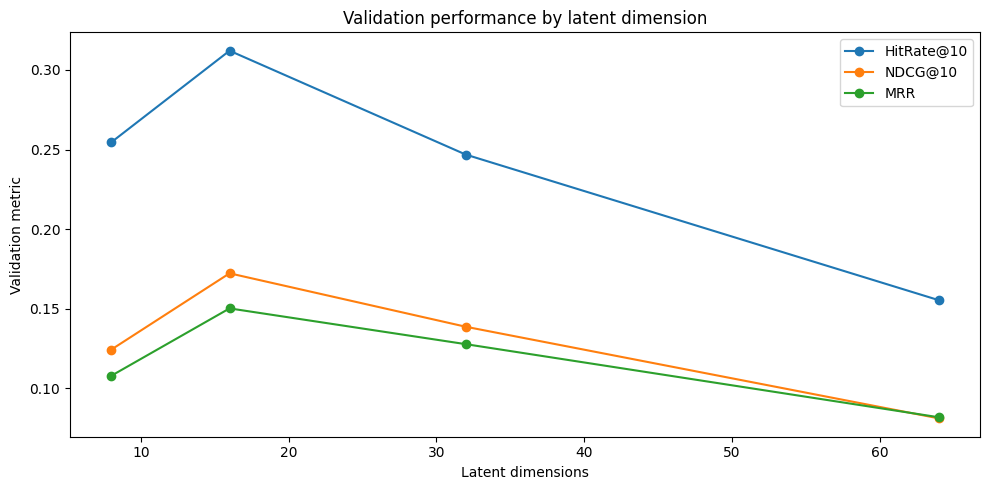

In [12]:
validation_plot_df = validation_results_df.sort("n_components").to_pandas()

plt.figure(figsize=(10, 5))
plt.plot(validation_plot_df["n_components"], validation_plot_df["hit_rate_at_k"], marker="o", label="HitRate@10")
plt.plot(validation_plot_df["n_components"], validation_plot_df["ndcg_at_k"], marker="o", label="NDCG@10")
plt.plot(validation_plot_df["n_components"], validation_plot_df["mrr"], marker="o", label="MRR")
plt.xlabel("Latent dimensions")
plt.ylabel("Validation metric")
plt.title("Validation performance by latent dimension")
plt.legend()
plt.tight_layout()
plt.show()

## Prediction Utilities

1. **user-to-video recommendations**: predicted affinity scores for unseen videos
2. **user-to-IP affinity**: aggregate predicted video scores by IP

For IP affinity, we use mean and max score over the top predicted unseen videos within each IP. 

In [13]:
def recommend_videos_for_user(
    user_id: str,
    user_factors: np.ndarray = best_user_factors,
    item_factors: np.ndarray = best_item_factors,
    top_k: int = 10,
    exclude_seen: bool = True,
    candidate_ip_names: list[str] | None = None,
) -> pl.DataFrame:
    if user_id not in user_to_idx:
        return pl.DataFrame()

    seen = all_user_histories.get(user_id, set())
    candidate_video_ids = list(video_to_idx.keys())
    if exclude_seen:
        candidate_video_ids = [video_id for video_id in candidate_video_ids if video_id not in seen]
    if candidate_ip_names is not None:
        allowed = set(candidate_ip_names)
        candidate_video_ids = [
            video_id
            for video_id in candidate_video_ids
            if video_metadata_map.get(video_id, {}).get("ip_name") in allowed
        ]
    if not candidate_video_ids:
        return pl.DataFrame()

    scores = score_user_items(user_id, candidate_video_ids, user_factors, item_factors)
    rows = []
    for video_id, score in zip(candidate_video_ids, scores.tolist()):
        metadata = video_metadata_map.get(video_id, {})
        rows.append({
            "commenter_id": user_id,
            "video_id": video_id,
            "ip_name": metadata.get("ip_name"),
            "title": metadata.get("title"),
            "view_count": metadata.get("view_count"),
            "comment_count": metadata.get("comment_count"),
            "predicted_score": score,
        })

    return (
        pl.DataFrame(rows)
        .sort("predicted_score", descending=True)
        .head(top_k)
    )


def score_ips_for_user(
    user_id: str,
    user_factors: np.ndarray = best_user_factors,
    item_factors: np.ndarray = best_item_factors,
    per_ip_top_k: int = 5,
) -> pl.DataFrame:
    recommendation_df = recommend_videos_for_user(
        user_id,
        user_factors=user_factors,
        item_factors=item_factors,
        top_k=len(video_to_idx),
        exclude_seen=True,
    )
    if recommendation_df.is_empty():
        return pl.DataFrame()

    ranked_df = (
        recommendation_df
        .with_columns(
            pl.col("predicted_score").rank(method="ordinal", descending=True).over("ip_name").alias("ip_rank")
        )
        .filter(pl.col("ip_rank") <= per_ip_top_k)
        .group_by("ip_name")
        .agg([
            pl.len().alias("candidate_videos_considered"),
            pl.col("predicted_score").mean().alias("mean_topk_video_score"),
            pl.col("predicted_score").max().alias("best_video_score"),
        ])
        .sort(["mean_topk_video_score", "best_video_score"], descending=[True, True])
    )
    return ranked_df

In [14]:
example_user_id = (
    train_df
    .group_by("commenter_id")
    .agg(pl.len().alias("train_rows"))
    .sort("train_rows", descending=True)
    .row(0, named=True)["commenter_id"]
)

print({"example_user_id": example_user_id})

recommend_videos_for_user(example_user_id, top_k=10)

{'example_user_id': 'UCRWKz5YYl24Ag7dZXHWLncg'}


commenter_id,video_id,ip_name,title,view_count,comment_count,predicted_score
str,str,str,str,i64,i64,f64
"""UCRWKz5YYl24Ag7dZXHWLncg""","""IHWlvwu8t1w""","""Star Wars""","""The Mandalorian and Grogu | Of…",11642821,9375,1.411509
"""UCRWKz5YYl24Ag7dZXHWLncg""","""DkVepshZhGc""","""Star Wars""","""Star Wars: Maul - Shadow Lord …",2006644,4737,0.7691
"""UCRWKz5YYl24Ag7dZXHWLncg""","""_pa1KLXuW0Y""","""Star Wars""","""The Mandalorian and Grogu | Of…",12550563,13238,0.749445
"""UCRWKz5YYl24Ag7dZXHWLncg""","""TaKrm5txGCQ""","""Star Wars""","""Andor | Maarva Andor’s Monolog…",3881647,7388,0.428042
"""UCRWKz5YYl24Ag7dZXHWLncg""","""J_1EXWNETiI""","""Star Wars""","""Ahsoka | Official Trailer | Di…",9970010,15937,0.41001
"""UCRWKz5YYl24Ag7dZXHWLncg""","""9Ehs9rv0s4A""","""Star Wars""","""Ahsoka Tano vs The Inquisitor …",5668771,5788,0.347094
"""UCRWKz5YYl24Ag7dZXHWLncg""","""TWTfhyvzTx0""","""Star Wars""","""Obi-Wan Kenobi | Teaser Traile…",19902792,34301,0.323455
"""UCRWKz5YYl24Ag7dZXHWLncg""","""wHuWmjXsReU""","""Marvel""","""Marvel Television’s Wonder Man…",14693922,7278,0.318774
"""UCRWKz5YYl24Ag7dZXHWLncg""","""pPhEsoSAhvY""","""Star Wars""","""Andor - The Best Show At The W…",1528472,9629,0.307921


In [15]:
score_ips_for_user(example_user_id, per_ip_top_k=5)

ip_name,candidate_videos_considered,mean_topk_video_score,best_video_score
str,u32,f64,f64
"""Star Wars""",5,0.753621,1.411509
"""Marvel""",5,0.231301,0.318774
"""Warhammer 40K""",5,0.177554,0.233294
"""Harry Potter""",5,0.087459,0.120604
"""Dungeons & Dragons""",5,0.059015,0.078055
"""Pokemon""",5,0.034507,0.044014


## Undirected IP-IP Co-Affinity From User Preference Profiles

The directional `source -> target` view can be useful, but your main idea is better represented as an **undirected connection** between IPs.

Here we treat each user as contributing a weighted signal to the IPs they appear to like under the recommender:

1. score unseen videos for the user
2. aggregate those video scores to an IP-level preference profile
3. normalize that user's IP scores into a probability distribution using **softmax**. Users are comparable and SVD's negative scores are normalized to proper probability distributioon
4. for every unordered pair of IPs, compute that user's contribution as:

`pair_contribution = p(ip_a | user) * p(ip_b | user)`

The temperature `SOFTMAX_TEMPERATURE` controls how peaked the per-user distribution is: lower temperature makes the user's strongest IP dominate, higher temperature spreads the mass.

- users who strongly like both IPs add more signal to that connection
- users with diffuse preferences contribute less to any one pair
- the final network is **undirected** because `(IP A, IP B)` is the same as `(IP B, IP A)`


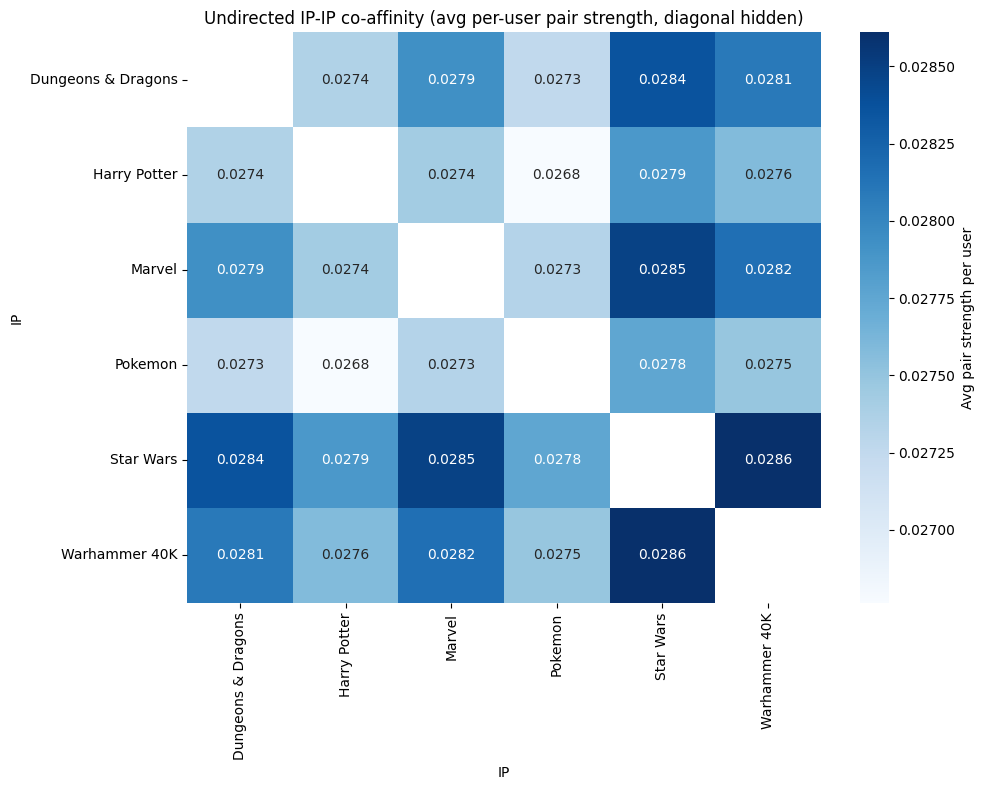

,IP A,IP B,Users Contributing,Total Pair Strength,Avg Pair Strength Per User,Median Pair Strength Per User
0,Star Wars,Warhammer 40K,10879,311.250,0.02861,0.02799
1,Marvel,Star Wars,10879,309.905,0.02849,0.02770
2,Dungeons & Dragons,Star Wars,10879,308.538,0.02836,0.02803
3,Marvel,Warhammer 40K,10879,306.309,0.02816,0.02778
4,Dungeons & Dragons,Warhammer 40K,10879,305.671,0.02810,0.02804
5,Dungeons & Dragons,Marvel,10879,303.825,0.02793,0.02778
6,Harry Potter,Star Wars,10879,303.116,0.02786,0.02767
7,Pokemon,Star Wars,10879,301.954,0.02776,0.02765
8,Harry Potter,Warhammer 40K,10879,300.096,0.02758,0.02770
9,Pokemon,Warhammer 40K,10879,299.049,0.02749,0.02767


ip_a,ip_b,users_contributing,total_pair_strength,avg_pair_strength_per_user,median_pair_strength_per_user
str,str,u32,f64,f64,f64
"""Star Wars""","""Warhammer 40K""",10879,311.250419,0.02861,0.027992
"""Marvel""","""Star Wars""",10879,309.90485,0.028487,0.027705
"""Dungeons & Dragons""","""Star Wars""",10879,308.537954,0.028361,0.028027
"""Marvel""","""Warhammer 40K""",10879,306.308815,0.028156,0.027784
"""Dungeons & Dragons""","""Warhammer 40K""",10879,305.671479,0.028097,0.028036
…,…,…,…,…,…
"""Harry Potter""","""Marvel""",10879,298.388872,0.027428,0.027417
"""Dungeons & Dragons""","""Harry Potter""",10879,297.590865,0.027355,0.027612
"""Marvel""","""Pokemon""",10879,297.335339,0.027331,0.027378


In [20]:
import seaborn as sns

SOFTMAX_TEMPERATURE = 1.0

undirected_user_ip_rows = []
for user_id in train_user_ids:
    user_ip_scores_df = score_ips_for_user(user_id, per_ip_top_k=5)
    if user_ip_scores_df.is_empty():
        continue

    raw_scores = user_ip_scores_df.get_column("mean_topk_video_score").to_numpy().astype(float)
    if raw_scores.size == 0 or not np.isfinite(raw_scores).all():
        continue

    shifted = raw_scores / SOFTMAX_TEMPERATURE
    shifted -= shifted.max()
    weights = np.exp(shifted)
    total_weight = float(weights.sum())
    if total_weight <= 0:
        continue
    softmax_probs = weights / total_weight

    normalized_df = user_ip_scores_df.with_columns(
        pl.Series("normalized_ip_score", softmax_probs)
    )

    for row in normalized_df.iter_rows(named=True):
        undirected_user_ip_rows.append({
            "commenter_id": user_id,
            "ip_name": row["ip_name"],
            "normalized_ip_score": row["normalized_ip_score"],
            "mean_topk_video_score": row["mean_topk_video_score"],
            "best_video_score": row["best_video_score"],
        })

undirected_user_ip_df = pl.DataFrame(undirected_user_ip_rows)

pair_rows = []
for user_id, user_df in undirected_user_ip_df.partition_by("commenter_id", as_dict=True).items():
    user_rows = sorted(user_df.iter_rows(named=True), key=lambda row: row["ip_name"])
    for i in range(len(user_rows)):
        for j in range(i + 1, len(user_rows)):
            left = user_rows[i]
            right = user_rows[j]
            pair_rows.append({
                "commenter_id": user_id,
                "ip_a": left["ip_name"],
                "ip_b": right["ip_name"],
                "user_pair_contribution": left["normalized_ip_score"] * right["normalized_ip_score"],
                "left_norm_score": left["normalized_ip_score"],
                "right_norm_score": right["normalized_ip_score"],
            })

user_ip_pair_df = pl.DataFrame(pair_rows)

undirected_ip_affinity_df = (
    user_ip_pair_df
    .group_by(["ip_a", "ip_b"])
    .agg([
        pl.len().alias("users_contributing"),
        pl.col("user_pair_contribution").sum().alias("total_pair_strength"),
        pl.col("user_pair_contribution").mean().alias("avg_pair_strength_per_user"),
        pl.col("user_pair_contribution").median().alias("median_pair_strength_per_user"),
    ])
    .sort(["total_pair_strength", "users_contributing"], descending=[True, True])
)

all_ips = sorted(undirected_user_ip_df.get_column("ip_name").unique().to_list())
heatmap_rows = []
for ip_left in all_ips:
    for ip_right in all_ips:
        if ip_left == ip_right:
            strength = np.nan
        else:
            left_ip = min(ip_left, ip_right)
            right_ip = max(ip_left, ip_right)
            match = undirected_ip_affinity_df.filter(
                (pl.col("ip_a") == left_ip) & (pl.col("ip_b") == right_ip)
            )
            strength = (
                float(match.row(0, named=True)["avg_pair_strength_per_user"])
                if match.height > 0
                else 0.0
            )
        heatmap_rows.append({
            "ip_left": ip_left,
            "ip_right": ip_right,
            "avg_pair_strength_per_user": strength,
        })

undirected_ip_heatmap_df = pl.DataFrame(heatmap_rows)
undirected_ip_heatmap_pd = undirected_ip_heatmap_df.to_pandas().pivot(
    index="ip_left",
    columns="ip_right",
    values="avg_pair_strength_per_user",
).loc[all_ips, all_ips]

mask = np.eye(len(all_ips), dtype=bool)
plt.figure(figsize=(10, 8))
sns.heatmap(
    undirected_ip_heatmap_pd,
    annot=True,
    fmt=".4f",
    cmap="Blues",
    mask=mask,
    cbar_kws={"label": "Avg pair strength per user"},
)
plt.title("Undirected IP-IP co-affinity (avg per-user pair strength, diagonal hidden)")
plt.xlabel("IP")
plt.ylabel("IP")
plt.tight_layout()
plt.show()

pretty_undirected_ip_affinity_table = (
    undirected_ip_affinity_df
    .select([
        pl.col("ip_a").alias("IP A"),
        pl.col("ip_b").alias("IP B"),
        pl.col("users_contributing").alias("Users Contributing"),
        pl.col("total_pair_strength").round(3).alias("Total Pair Strength"),
        pl.col("avg_pair_strength_per_user").round(5).alias("Avg Pair Strength Per User"),
        pl.col("median_pair_strength_per_user").round(5).alias("Median Pair Strength Per User"),
    ])
    .head(15)
    .to_pandas()
)

display(pretty_undirected_ip_affinity_table)

undirected_ip_affinity_df

In [21]:
from pathlib import Path
import polars as pl

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED_DIR = ROOT / "data" / "processed"
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

test_summary_df = pl.DataFrame([{"best_n_components": best_n_components, **test_summary}])
validation_results_df.write_parquet(DATA_PROCESSED_DIR / "cf_validation_results.parquet")
test_summary_df.write_parquet(DATA_PROCESSED_DIR / "cf_test_results.parquet")

num_users, num_videos = train_matrix.shape
observed_entries = int(train_matrix.nnz)
train_matrix_stats_df = pl.DataFrame([{
    "num_users": num_users,
    "num_videos": num_videos,
    "observed_user_video_pairs": observed_entries,
    "total_possible_user_video_pairs": num_users * num_videos,
    "matrix_density": observed_entries / (num_users * num_videos),
    "matrix_sparsity": 1 - observed_entries / (num_users * num_videos),
    "avg_train_interactions_per_user": observed_entries / num_users,
    "avg_train_users_per_video": observed_entries / num_videos,
}])
train_matrix_stats_df.write_parquet(DATA_PROCESSED_DIR / "cf_train_matrix_stats.parquet")

undirected_ip_affinity_df.write_parquet(DATA_PROCESSED_DIR / "cf_ip_affinity.parquet")

In [22]:
con.close()